# Digital Transformation and Inclusion in East Africa

### Client
East African Communications Organisation (EACO)

### Data Source
World Bank Indicators API

### Period
2010–2024

### Analytical Objective
To evaluate digital transformation and digital inclusion across selected East African countries and identify priority areas for investment.

### Research Questions

1. Which East African country has experienced the highest growth in internet users between 2010 and 2024?
2. How does internet penetration compare with mobile-phone subscriptions across the selected countries?
3. Is access to electricity associated with higher internet usage?
4. Which country has the largest gap between mobile-phone subscriptions and internet adoption?
5. How does Kenya compare with the other East African countries in terms of digital transformation?
6. Which three policy interventions would accelerate digital inclusion within the East African region?

# Setting the Environment and Data Preparation

In [58]:
!pip install requests pandas matplotlib seaborn -q

In [59]:
!pip install scipy scikit-learn -q

## API Documentation

| Item | Value |
|---|---|
| Base URL | `https://api.worldbank.org/v2` |
| Country list endpoint | `/country?format=json&per_page=300&region=SSF` |
| Indicator search endpoint | `/indicator?format=json&per_page=...` |
| Data endpoint | `/country/{code}/indicator/{indicator}` |
| Data parameters | `format=json`, `date=2010:2024`, `per_page=100` |

| Indicator code | Variable | Role |
|---|---|---|
| IT.NET.USER.ZS | Internet users (% of population) | Outcome |
| IT.CEL.SETS.P2 | Mobile subscriptions (per 100 people) | Comparison / usage gap |
| EG.ELC.ACCS.ZS | Access to electricity (% of population) | Enabling infrastructure |

**Country selection:** we use the East African countries within EACO's footprint
(Burundi, Ethiopia, Kenya, Rwanda, Somalia, South Sudan, Tanzania, Uganda).
Selection is by ISO3 code, not name matching, for robustness.

In [60]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")


# World Bank API base URL
BASE_URL = "http://api.worldbank.org/v2"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### As we are working with countries in East Africa we need to fetch first their country_codes directly from the world Bank API

In [61]:
# Fetch country codes directly from World Bank API
response = requests.get(
    f"{BASE_URL}/country",
    params={
        "format": "json",
        "per_page": 300,
        "region": "SSF"  # Sub-Saharan Africa
    }
)

data = response.json()
countries_df = pd.DataFrame([
    {
        'country_code': c['id'],
        'iso3_code': c['iso2Code'],
        'country_name': c['name'],
        'region': c['region']['value'],
        'income_level': c['incomeLevel']['value']
    }
    for c in data[1]
    if c['region']['value'] != 'Aggregates'
])

# Filter for East African countries
east_africa = ['Burundi', 'Kenya', 'Rwanda', 'Somalia',
               'South Sudan', 'Tanzania', 'Uganda', 'Ethiopia']

ea_df = countries_df[countries_df['country_name'].str.contains(
    '|'.join(east_africa), case=False, na=False
)]

print("East African Countries from World Bank API:")
print(ea_df[['country_code', 'country_name']].to_string(index=False))

East African Countries from World Bank API:
country_code       country_name
         BDI            Burundi
         ETH           Ethiopia
         KEN              Kenya
         RWA             Rwanda
         SOM Somalia, Fed. Rep.
         SSD        South Sudan
         TZA           Tanzania
         UGA             Uganda


## The analysis uses three primary World Bank indicators:

### 1. Internet users (% of population)
### 2. Mobile cellular subscriptions (per 100 people)
### 3. Access to electricity (% of population)

## First check all available indicators in the World Bank API

In [62]:


print("Fetching all indicators from World Bank API...")

response = requests.get(
    f"{BASE_URL}/indicator",
    params={
        "format": "json",
        "per_page": 20000
    }
)

data = response.json()
total = data[0]['total']
print(f"Total indicators available: {total}")

# Convert to DataFrame
all_indicators = pd.DataFrame([
    {
        'code': item['id'],
        'name': item['name'],
    }
    for item in data[1]
])

print(f"Indicators loaded: {len(all_indicators)}")

# Search 1: Internet users
internet = all_indicators[
    all_indicators['name'].str.contains('Internet', case=False, na=False) &
    all_indicators['name'].str.contains('population', case=False, na=False)
]
print("\n1. INTERNET USERS indicators found:")
print(internet[['code', 'name']].to_string(index=False))

# Search 2: Mobile subscriptions
mobile = all_indicators[
    all_indicators['name'].str.contains('cellular', case=False, na=False) &
    all_indicators['name'].str.contains('subscription', case=False, na=False)
]
print("\n2. MOBILE SUBSCRIPTION indicators found:")
print(mobile[['code', 'name']].to_string(index=False))

# Search 3: Electricity access
electricity = all_indicators[
    all_indicators['name'].str.contains('electricity', case=False, na=False) &
    all_indicators['name'].str.contains('access', case=False, na=False)
]
print("\n3. ELECTRICITY ACCESS indicators found:")
print(electricity[['code', 'name']].to_string(index=False))

Fetching all indicators from World Bank API...
Total indicators available: 29544
Indicators loaded: 20000

1. INTERNET USERS indicators found:
             code                                                            name
IT.NET.USER.FE.ZS Individuals using the Internet, female (% of female population)
IT.NET.USER.MA.ZS     Individuals using the Internet, male (% of male population)
   IT.NET.USER.ZS                Individuals using the Internet (% of population)

2. MOBILE SUBSCRIPTION indicators found:
           code                                                          name
    IT.CEL.SETS                                 Mobile cellular subscriptions
 IT.CEL.SETS.P2                Mobile cellular subscriptions (per 100 people)
IT.CELL.MSUB.CD            Mobile cellular monthly subscription (current US$)
IT.CELL.MSUB.CN            Mobile cellular monthly subscription (current LCU)
 IT.TEL.TOTL.EM     Fixed line and mobile cellular subscriptions per employee
 IT.TEL.TOTL.P2 Fix

## Search for required indicators for the 3 concerned areas in this project

In [63]:

print("=" * 60)
print("SEARCHING FOR OUR INDICATORS FROM AVAILABLE LIST")
print("=" * 60)

# Search 1: Internet users
internet = all_indicators[
    all_indicators['name'].str.contains('Internet', case=False, na=False) &
    all_indicators['name'].str.contains('population', case=False, na=False)
]
print("\n1. INTERNET USERS indicators found:")
print(internet[['code', 'name']].to_string(index=False))

# Search 2: Mobile subscriptions
mobile = all_indicators[
    all_indicators['name'].str.contains('cellular', case=False, na=False) &
    all_indicators['name'].str.contains('subscription', case=False, na=False)
]
print("\n2. MOBILE SUBSCRIPTION indicators found:")
print(mobile[['code', 'name']].to_string(index=False))

# Search 3: Electricity access
electricity = all_indicators[
    all_indicators['name'].str.contains('electricity', case=False, na=False) &
    all_indicators['name'].str.contains('access', case=False, na=False)
]
print("\n3. ELECTRICITY ACCESS indicators found:")
print(electricity[['code', 'name']].to_string(index=False))

SEARCHING FOR OUR INDICATORS FROM AVAILABLE LIST

1. INTERNET USERS indicators found:
             code                                                            name
IT.NET.USER.FE.ZS Individuals using the Internet, female (% of female population)
IT.NET.USER.MA.ZS     Individuals using the Internet, male (% of male population)
   IT.NET.USER.ZS                Individuals using the Internet (% of population)

2. MOBILE SUBSCRIPTION indicators found:
           code                                                          name
    IT.CEL.SETS                                 Mobile cellular subscriptions
 IT.CEL.SETS.P2                Mobile cellular subscriptions (per 100 people)
IT.CELL.MSUB.CD            Mobile cellular monthly subscription (current US$)
IT.CELL.MSUB.CN            Mobile cellular monthly subscription (current LCU)
 IT.TEL.TOTL.EM     Fixed line and mobile cellular subscriptions per employee
 IT.TEL.TOTL.P2 Fixed line and mobile cellular subscriptions (per 100 people

## Verify that each country code exist in the API

In [64]:


print("Step 1: Fetching country codes from World Bank API...")
response = requests.get(
    f"{BASE_URL}/country",
    params={"format": "json", "per_page": 300}
)
data = response.json()
all_countries = pd.DataFrame([
    {'code': c['id'], 'name': c['name']}
    for c in data[1]
    if c['region']['value'] != 'Aggregates'
])

# Filter East African countries
ea_names = ['Burundi','Ethiopia','Kenya','Rwanda',
            'Somalia','South Sudan','Tanzania','Uganda']
ea_countries = all_countries[
    all_countries['name'].str.contains('|'.join(ea_names), case=False, na=False)
]
print("\nVerified East African Countries:")
print(ea_countries.to_string(index=False))

# Build COUNTRIES dictionary from API results
COUNTRIES = dict(zip(ea_countries['code'], ea_countries['name']))
print(f"\nCOUNTRIES dictionary: {COUNTRIES}")

# Step 2: Fetch and verify indicators from API
print("\nStep 2: Fetching indicators from World Bank API...")
response = requests.get(
    f"{BASE_URL}/indicator",
    params={"format": "json", "per_page": 20000}
)
data = response.json()
all_indicators = pd.DataFrame([
    {'code': item['id'], 'name': item['name']}
    for item in data[1]
])
print(f"Total indicators available: {len(all_indicators)}")

# Search for our 3 indicators
internet = all_indicators[
    all_indicators['name'].str.contains('Internet', case=False, na=False) &
    all_indicators['name'].str.contains('population', case=False, na=False)
]
print("\n1. INTERNET indicators found:")
print(internet[['code','name']].head(5).to_string(index=False))

mobile = all_indicators[
    all_indicators['name'].str.contains('cellular', case=False, na=False) &
    all_indicators['name'].str.contains('subscription', case=False, na=False)
]
print("\n2. MOBILE indicators found:")
print(mobile[['code','name']].head(5).to_string(index=False))

electricity = all_indicators[
    all_indicators['name'].str.contains('electricity', case=False, na=False) &
    all_indicators['name'].str.contains('access', case=False, na=False)
]
print("\n3. ELECTRICITY indicators found:")
print(electricity[['code','name']].head(5).to_string(index=False))

# Step 3: Define verified INDICATORS dictionary
INDICATORS = {
    'IT.NET.USER.ZS': 'Internet_Users_Pct',
    'IT.CEL.SETS.P2': 'Mobile_Subscriptions_Per100',
    'EG.ELC.ACCS.ZS': 'Electricity_Access_Pct'
}

# Confirm each code exists in API
print("\nStep 3: Confirming our indicator codes exist in API...")
for code, name in INDICATORS.items():
    match = all_indicators[all_indicators['code'] == code]
    if len(match) > 0:
        print(f"✅ {name}: {match['name'].values[0]}")
    else:
        print(f"❌ NOT FOUND: {code}")

print("\nSetup complete — COUNTRIES and INDICATORS verified from API")

Step 1: Fetching country codes from World Bank API...

Verified East African Countries:
code               name
 BDI            Burundi
 ETH           Ethiopia
 KEN              Kenya
 RWA             Rwanda
 SOM Somalia, Fed. Rep.
 SSD        South Sudan
 TZA           Tanzania
 UGA             Uganda

COUNTRIES dictionary: {'BDI': 'Burundi', 'ETH': 'Ethiopia', 'KEN': 'Kenya', 'RWA': 'Rwanda', 'SOM': 'Somalia, Fed. Rep.', 'SSD': 'South Sudan', 'TZA': 'Tanzania', 'UGA': 'Uganda'}

Step 2: Fetching indicators from World Bank API...
Total indicators available: 20000

1. INTERNET indicators found:
             code                                                            name
IT.NET.USER.FE.ZS Individuals using the Internet, female (% of female population)
IT.NET.USER.MA.ZS     Individuals using the Internet, male (% of male population)
   IT.NET.USER.ZS                Individuals using the Internet (% of population)

2. MOBILE indicators found:
           code                          

In [65]:
# =====================================================================
# DATA RETRIEVAL (corrected)
# Changes from v1:
#   1. Added date=2010:2024 parameter -> no pre-study-period data
#   2. Nulls are RETAINED at fetch time. Dropping them here would make
#      the Data Quality Assessment impossible (we could not measure
#      missingness). Cleaning happens in a separate, documented step.
# =====================================================================
print("Fetching data from World Bank API...")

def fetch_indicator(indicator_code, countries_dict):
    """Fetch one indicator for the study countries, 2010-2024, keeping nulls."""
    all_data = []
    for country_code, country_name in countries_dict.items():
        response = requests.get(
            f"{BASE_URL}/country/{country_code}/indicator/{indicator_code}",
            params={"format": "json", "date": "2010:2024", "per_page": 100},
        )
        data = response.json()
        if len(data) > 1 and data[1]:
            for record in data[1]:
                all_data.append({
                    "country": country_name,
                    "country_code": country_code,
                    "year": int(record["date"]),
                    # value may be None -> NaN; kept deliberately for the DQA
                    "value": (float(record["value"])
                              if record["value"] is not None else np.nan),
                })
    return pd.DataFrame(all_data)

df_internet_raw = fetch_indicator("IT.NET.USER.ZS", COUNTRIES)
df_internet_raw["indicator"] = "Internet_Users_Pct"

df_mobile_raw = fetch_indicator("IT.CEL.SETS.P2", COUNTRIES)
df_mobile_raw["indicator"] = "Mobile_Subscriptions_Per100"

df_electric_raw = fetch_indicator("EG.ELC.ACCS.ZS", COUNTRIES)
df_electric_raw["indicator"] = "Electricity_Access_Pct"

df_all_raw = pd.concat([df_internet_raw, df_mobile_raw, df_electric_raw],
                       ignore_index=True)

print(f"Total records retrieved (incl. nulls): {len(df_all_raw)}")
print(f"Records with missing values: {df_all_raw['value'].isna().sum()}")

Fetching data from World Bank API...
Total records retrieved (incl. nulls): 360
Records with missing values: 15


# Data Quality Assessment
Checking for missing values, duplicate records, outliers,
data completeness, data consistency.

In [66]:
# =====================================================================
# DATA QUALITY ASSESSMENT
# =====================================================================

# ---- 1. MISSING VALUES: per indicator and per country ----
print("1. MISSING VALUES (% of 2010-2024 cells)")
miss = (df_all_raw.groupby("indicator")["value"]
        .apply(lambda s: s.isna().mean() * 100).round(1))
print(miss.to_frame("% missing"), "\n")

miss_country = df_all_raw.pivot_table(
    index="country", columns="indicator", values="value",
    aggfunc=lambda s: s.isna().mean() * 100).round(1)
print(miss_country, "\n")

# ---- 2. DUPLICATE RECORDS: same (country, year, indicator) twice ----
dups = df_all_raw.duplicated(subset=["country_code", "year", "indicator"]).sum()
print(f"2. DUPLICATE (country, year, indicator) records: {dups}\n")

# ---- 3. OUTLIERS: 1.5 x IQR rule within each indicator ----
print("3. OUTLIERS (1.5 x IQR within indicator)")
for ind, grp in df_all_raw.dropna(subset=["value"]).groupby("indicator"):
    q1, q3 = grp["value"].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (grp["value"] < q1 - 1.5 * iqr) | (grp["value"] > q3 + 1.5 * iqr)
    flagged = grp.loc[mask, ["country", "year", "value"]]
    print(f"  {ind}: {mask.sum()} flagged")
    if mask.sum():
        print(flagged.to_string(index=False))
print("  NOTE: for national statistics, IQR 'outliers' are usually genuine")
print("  cross-country differences, not errors. Flagged for review, not removed.\n")

# ---- 4. COMPLETENESS: % of expected country-year cells populated ----
n_countries = df_all_raw["country"].nunique()
n_years = df_all_raw["year"].nunique()
expected = n_countries * n_years
comp = (df_all_raw.groupby("indicator")["value"]
        .apply(lambda s: s.notna().sum() / expected * 100).round(1))
print("4. COMPLETENESS (% of expected cells populated)")
print(comp.to_frame("% complete"), "\n")

latest_avail = (df_all_raw.dropna(subset=["value"])
                .groupby("indicator")["year"].max())
print("Latest year with data per indicator:")
print(latest_avail.to_frame("latest year"), "\n")

# ---- 5. CONSISTENCY: values within plausible ranges ----
print("5. CONSISTENCY CHECKS")
pct = df_all_raw[df_all_raw["indicator"].isin(
    ["Internet_Users_Pct", "Electricity_Access_Pct"])]
print(f"  Percentage values < 0:   {(pct['value'] < 0).sum()}")
print(f"  Percentage values > 100: {(pct['value'] > 100).sum()}")
mob = df_all_raw[df_all_raw["indicator"] == "Mobile_Subscriptions_Per100"]
print(f"  Mobile subs > 100/100:   {(mob['value'] > 100).sum()} "
      "(VALID - multiple SIM ownership, not an error)")

1. MISSING VALUES (% of 2010-2024 cells)
                             % missing
indicator                             
Electricity_Access_Pct             0.0
Internet_Users_Pct                 8.3
Mobile_Subscriptions_Per100        4.2 

indicator           Electricity_Access_Pct  Internet_Users_Pct  \
country                                                          
Burundi                                0.0                 0.0   
Ethiopia                               0.0                 0.0   
Kenya                                  0.0                 0.0   
Rwanda                                 0.0                 0.0   
Somalia, Fed. Rep.                     0.0                20.0   
South Sudan                            0.0                46.7   
Tanzania                               0.0                 0.0   
Uganda                                 0.0                 0.0   

indicator           Mobile_Subscriptions_Per100  
country                                          
B

# Data Cleaning and Preparation

Preprocessing decisions:
1. **Missing values:** rows with null values are dropped for analysis, and each
   country's *latest available year* is used per indicator rather than forcing
   2024. Rationale: World Bank/ITU data lags 1–2 years; extrapolating to
   invent 2024 values would fabricate evidence. The year used is reported
   alongside each value.
2. **No interpolation:** series are analysed as reported. Interior gaps are
   small; interpolation would add assumptions without changing conclusions.
3. **Duplicates:** removed on (country, year, indicator), keeping first.
4. **Range checks:** percentage indicators clipped to [0, 100]. Mobile
   subscriptions NOT capped at 100, since >100 per 100 people reflects real
   multi-SIM ownership.

In [67]:
# =====================================================================
# CLEANING (produces the same variable names the analysis cells use)
# =====================================================================
df_clean = (df_all_raw
            .drop_duplicates(subset=["country_code", "year", "indicator"])
            .dropna(subset=["value"])
            .copy())

# Range check: clip percentage indicators to [0, 100]
pct_mask = df_clean["indicator"].isin(["Internet_Users_Pct",
                                       "Electricity_Access_Pct"])
df_clean.loc[pct_mask, "value"] = df_clean.loc[pct_mask, "value"].clip(0, 100)

df_internet = df_clean[df_clean["indicator"] == "Internet_Users_Pct"].copy()
df_mobile   = df_clean[df_clean["indicator"] == "Mobile_Subscriptions_Per100"].copy()
df_electric = df_clean[df_clean["indicator"] == "Electricity_Access_Pct"].copy()

# Transparency: report which "latest year" each comparison actually uses
latest_years = (df_clean.groupby(["indicator", "country"])["year"].max()
                .unstack(level=0))
print("Latest available year used per country and indicator:")
print(latest_years)

# Wide panel export -> data source for the dashboard
panel = (df_clean.pivot_table(index=["country_code", "country", "year"],
                              columns="indicator", values="value")
         .reset_index())
panel.columns.name = None
panel.to_csv("panel_clean.csv", index=False)
print("\nSaved panel_clean.csv (dashboard data source)")

Latest available year used per country and indicator:
indicator           Electricity_Access_Pct  Internet_Users_Pct  \
country                                                          
Burundi                               2024                2024   
Ethiopia                              2024                2024   
Kenya                                 2024                2024   
Rwanda                                2024                2024   
Somalia, Fed. Rep.                    2024                2024   
South Sudan                           2024                2019   
Tanzania                              2024                2024   
Uganda                                2024                2024   

indicator           Mobile_Subscriptions_Per100  
country                                          
Burundi                                    2023  
Ethiopia                                   2024  
Kenya                                      2024  
Rwanda                             

## 1. Which East African country has experienced the highest growth in internet users between 2010 and 2024?

Q1: Highest Growth in Internet Users (2010-2024)
                    Growth(%points)
country                            
Tanzania                      28.26
Kenya                         27.78
Rwanda                        23.70
Ethiopia                      21.19
Burundi                        7.60
Uganda                         4.65
Somalia, Fed. Rep.              NaN
South Sudan                     NaN

Country with HIGHEST growth: Tanzania
Growth: 28.26 percentage points


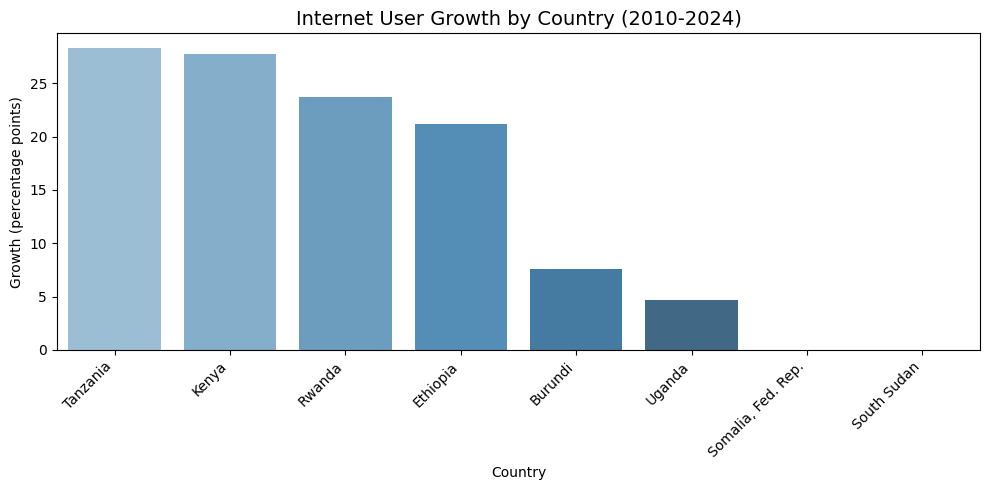

In [68]:
print("=" * 55)
print("Q1: Highest Growth in Internet Users (2010-2024)")
print("=" * 55)

# Get 2010 and most recent values per country
internet = df_internet.copy()

early = internet[internet['year'] == 2010].set_index('country')['value']
latest = internet[internet['year'] == internet.groupby('country')['year'].transform('max')]
latest = latest.groupby('country')['value'].last()

growth = (latest - early).sort_values(ascending=False)
growth.name = 'Growth(%points)'

print(growth.round(2).to_frame())
print(f"\nCountry with HIGHEST growth: {growth.idxmax()}")
print(f"Growth: {growth.max():.2f} percentage points")

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=growth.index, y=growth.values, hue=growth.index,
            palette='Blues_d', legend=False)
plt.xticks(rotation=45, ha='right')  # prevents label overlap
plt.title("Internet User Growth by Country (2010-2024)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Growth (percentage points)")
plt.tight_layout()
plt.show()

**Chart justification:** a sorted bar chart answers a ranking question at a glance. Best practices: sorted by value, zero-based axis, rotated labels to prevent overlap.

In [69]:
# =====================================================================
# STATISTICAL TECHNIQUE 1: TREND ANALYSIS (CAGR + absolute growth)
# CAGR complements percentage-point growth: countries starting near zero
# can have huge relative growth but small absolute gains.
# Uses each country's EARLIEST year >= 2010 (some lack a 2010 value).
# =====================================================================
trend_rows = []
for c, g in df_internet.sort_values("year").groupby("country"):
    start, end = g.iloc[0], g.iloc[-1]
    yrs = end["year"] - start["year"]
    cagr = (((end["value"] / start["value"]) ** (1 / yrs)) - 1) * 100 \
        if start["value"] > 0 and yrs > 0 else np.nan
    trend_rows.append({"country": c,
                       "start": f"{start['value']:.1f} ({int(start['year'])})",
                       "end": f"{end['value']:.1f} ({int(end['year'])})",
                       "growth_pp": round(end["value"] - start["value"], 2),
                       "CAGR_%": round(cagr, 2)})
trend_df = (pd.DataFrame(trend_rows)
            .sort_values("growth_pp", ascending=False))
print(trend_df.to_string(index=False))
print(f"\nHighest ABSOLUTE growth: {trend_df.iloc[0]['country']}")
print(f"Highest RELATIVE growth (CAGR): "
      f"{trend_df.loc[trend_df['CAGR_%'].idxmax(), 'country']}")

           country      start         end  growth_pp  CAGR_%
          Tanzania 2.9 (2010) 31.2 (2024)      28.26   18.48
             Kenya 7.2 (2010) 35.0 (2024)      27.78   11.95
Somalia, Fed. Rep. 1.2 (2011) 27.9 (2024)      26.69   27.00
            Rwanda 8.0 (2010) 31.7 (2024)      23.70   10.34
          Ethiopia 0.8 (2010) 21.9 (2024)      21.19   27.27
           Burundi 1.0 (2010)  8.6 (2024)       7.60   16.61
       South Sudan 1.5 (2012)  6.7 (2019)       5.17   23.76
            Uganda 4.3 (2010)  8.9 (2024)       4.65    5.38

Highest ABSOLUTE growth: Tanzania
Highest RELATIVE growth (CAGR): Ethiopia


## 2. How does internet penetration compare with mobile-phone subscriptions across the selected countries?

Q2: Internet Penetration vs Mobile Subscriptions
                    Internet_Users(%)  Mobile_Subscriptions(per100)
country                                                            
Kenya                           34.98                        126.48
Rwanda                          31.70                         93.20
Tanzania                        31.16                        126.56
Somalia, Fed. Rep.              27.94                         53.96
Ethiopia                        21.94                         65.08
Uganda                           8.95                         83.17
Burundi                          8.60                         63.16
South Sudan                      6.67                         46.62


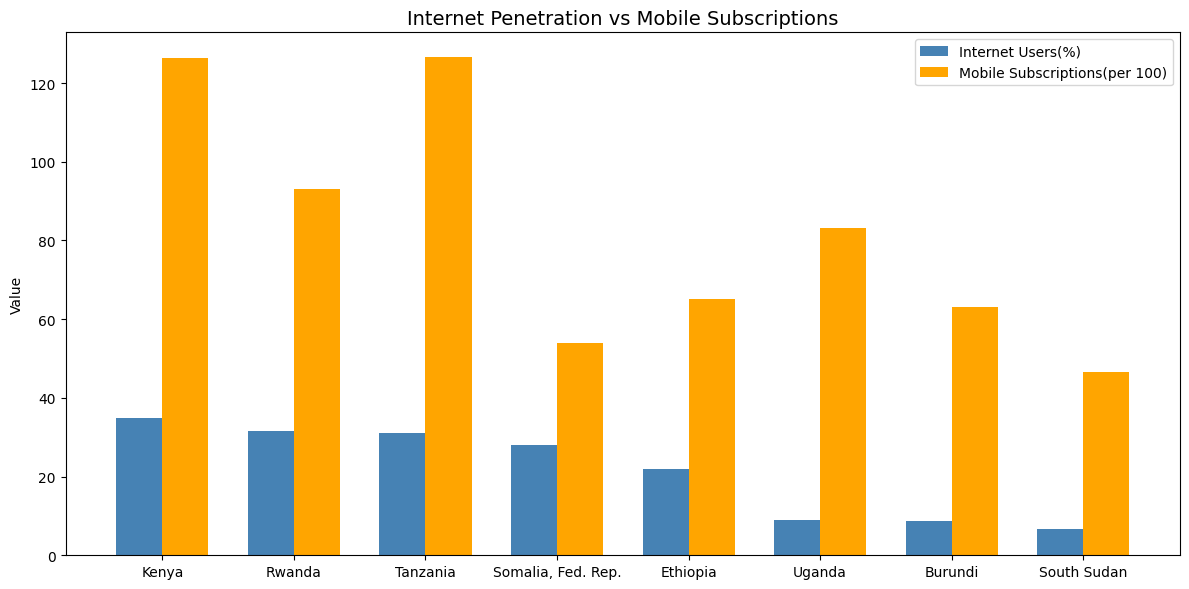

In [70]:
print("=" * 55)
print("Q2: Internet Penetration vs Mobile Subscriptions")
print("=" * 55)

# Get latest values for each country
latest_internet = df_internet.groupby('country').apply(
    lambda x: x.loc[x['year'].idxmax(), 'value']
).round(2)
latest_mobile = df_mobile.groupby('country').apply(
    lambda x: x.loc[x['year'].idxmax(), 'value']
).round(2)

comparison = pd.DataFrame({
    'Internet_Users(%)': latest_internet,
    'Mobile_Subscriptions(per100)': latest_mobile
}).sort_values('Internet_Users(%)', ascending=False)

print(comparison)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(comparison))
width = 0.35
ax.bar([i - width/2 for i in x], comparison['Internet_Users(%)'],
       width, label='Internet Users(%)', color='steelblue')
ax.bar([i + width/2 for i in x], comparison['Mobile_Subscriptions(per100)'],
       width, label='Mobile Subscriptions(per 100)', color='orange')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index)
ax.set_title("Internet Penetration vs Mobile Subscriptions", fontsize=14)
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()



**Chart justification:** grouped bars compare two related measures per country side by side. Both measures are per-100-population, so a shared axis is valid. Best practices: consistent colours, legend, direct comparison within each country group.

## Comment:
Mobile subscriptions far exceed internet penetration in all countries. This shows mobile are widely owned but internet adoption lags behind.

## 3. Is access to electricity associated with higher internet usage?

Q3: Electricity Access vs Internet Usage
                    Electricity_Access(%)  Internet_Users(%)
country                                                     
Kenya                                77.0              34.98
Rwanda                               72.0              31.70
Ethiopia                             56.6              21.94
Uganda                               55.3               8.95
Somalia, Fed. Rep.                   54.4              27.94
Tanzania                             52.4              31.16
Burundi                              20.1               8.60
South Sudan                           5.4               6.67
POOLED PANEL (n=110):
  Pearson  r   = 0.744  (p = 1.24e-20)
  Spearman rho = 0.683  (p = 1.97e-16)

LATEST-YEAR CROSS-SECTION (n=7):
  Pearson r = 0.739 (p = 0.058) - interpret cautiously, small n

Correlation between Electricity and Internet: 0.744


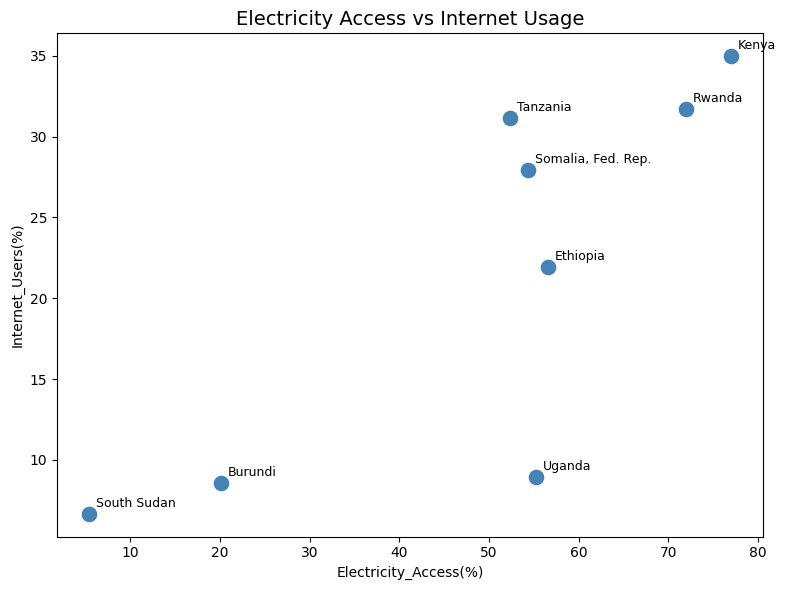

In [71]:
from scipy import stats
print("=" * 55)
print("Q3: Electricity Access vs Internet Usage")
print("=" * 55)

latest_electric = df_electric.groupby('country').apply(
    lambda x: x.loc[x['year'].idxmax(), 'value']
).round(2)

assoc = pd.DataFrame({
    'Electricity_Access(%)': latest_electric,
    'Internet_Users(%)': latest_internet
}).sort_values('Electricity_Access(%)', ascending=False)

print(assoc)

# =====================================================================
# STATISTICAL TECHNIQUE: CORRELATION (Pearson + Spearman, with p-values)
# Pooled panel (all country-years) gives n~100+, so the test has power.
# The latest-year cross-section (n=8) is reported too, but note its p-value:
# small samples rarely reach significance even when the association is real.
# =====================================================================
merged = pd.merge(
    df_electric[["country", "year", "value"]].rename(columns={"value": "electricity"}),
    df_internet[["country", "year", "value"]].rename(columns={"value": "internet"}),
    on=["country", "year"])

pr, pp = stats.pearsonr(merged["electricity"], merged["internet"])
sr, sp = stats.spearmanr(merged["electricity"], merged["internet"])
print(f"POOLED PANEL (n={len(merged)}):")
print(f"  Pearson  r   = {pr:.3f}  (p = {pp:.2e})")
print(f"  Spearman rho = {sr:.3f}  (p = {sp:.2e})")

cross = merged[merged["year"] == merged["year"].max()]
if len(cross) >= 3:
    cr, cp = stats.pearsonr(cross["electricity"], cross["internet"])
    print(f"\nLATEST-YEAR CROSS-SECTION (n={len(cross)}):")
    print(f"  Pearson r = {cr:.3f} (p = {cp:.3f}) "
          "- interpret cautiously, small n")

corr = round(pr, 3)
print(f"\nCorrelation between Electricity and Internet: {corr}")

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=assoc, x='Electricity_Access(%)',
                y='Internet_Users(%)', s=150, color='steelblue')
for idx, row in assoc.iterrows():
    plt.annotate(idx, (row['Electricity_Access(%)'],
                 row['Internet_Users(%)']), textcoords="offset points",
                 xytext=(5,5), fontsize=9)
plt.title("Electricity Access vs Internet Usage", fontsize=14)
plt.tight_layout()
plt.show()


**Chart justification:** a scatter plot is the canonical display of association between two continuous variables; point labels identify countries. Best practices: labelled points, correlation coefficient reported with the chart, both axes start at comparable scales.

## Comment:
Based on the analytics above, we find that countries with higher electricity access tend to have higher internet usage. This confirms electricity is a foundational requirement for digital transformation. Meaning, without poer, devices cannot be charged or connected

```
# This is formatted as code
```



In [72]:
!pip install statsmodels -q
# =====================================================================
# STATISTICAL TECHNIQUE 3: OLS REGRESSION
# Does electricity access predict internet use after controlling for
# mobile subscriptions? Clustered SEs account for repeated obs per country.
# =====================================================================
import statsmodels.api as sm

reg = pd.merge(merged,
               df_mobile[["country", "year", "value"]].rename(columns={"value": "mobile"}),
               on=["country", "year"]).dropna()
X = sm.add_constant(reg[["electricity", "mobile"]])
model = sm.OLS(reg["internet"], X).fit(
    cov_type="cluster", cov_kwds={"groups": reg["country"]})
print(model.summary())

# =====================================================================
# STATISTICAL TECHNIQUE 4: FORECASTING (Holt's linear trend to 2028)
# Sizes the divergence risk for the policy recommendations: on current
# trends, do lagging countries catch up or fall further behind?
# =====================================================================
from statsmodels.tsa.holtwinters import Holt

fc_rows = []
for c, g in df_internet.sort_values("year").groupby("country"):
    if len(g) < 6:          # too short for a reliable trend fit
        continue
    series = g.set_index("year")["value"]
    fit = Holt(series, initialization_method="estimated").fit(optimized=True)
    last_year = int(series.index.max())
    steps = 2028 - last_year
    fc = fit.forecast(steps).clip(0, 100)
    # enumerate from the last observed year: avoids the positional-index
    # bug where statsmodels returns 15,16,17,18 instead of calendar years
    for i, val in enumerate(fc.values, start=1):
        fc_rows.append({"country": c, "year": last_year + i,
                        "forecast_%": round(float(val), 2)})

fc_df = pd.DataFrame(fc_rows)
print("\nForecast internet users in 2028 (%):")
print(fc_df[fc_df["year"] == 2028]
      .sort_values("forecast_%", ascending=False).to_string(index=False))

                            OLS Regression Results                            
Dep. Variable:               internet   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     49.86
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           7.23e-05
Time:                        20:53:24   Log-Likelihood:                -320.91
No. Observations:                 107   AIC:                             647.8
Df Residuals:                     104   BIC:                             655.8
Df Model:                           2                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.9880      1.829     -2.727      

## 4. Which country has the largest gap between mobile-phone ownership and internet adoption?

Q4: Gap Between Mobile and Internet Adoption
                    Mobile_Subscriptions(per100)  Internet_Users(%)    Gap
country                                                                   
Tanzania                                  126.56              31.16  95.40
Kenya                                     126.48              34.98  91.50
Uganda                                     83.17               8.95  74.22
Rwanda                                     93.20              31.70  61.50
Burundi                                    63.16               8.60  54.56
Ethiopia                                   65.08              21.94  43.14
South Sudan                                46.62               6.67  39.95
Somalia, Fed. Rep.                         53.96              27.94  26.02

Country with LARGEST gap: Tanzania
Gap size: 95.40 points


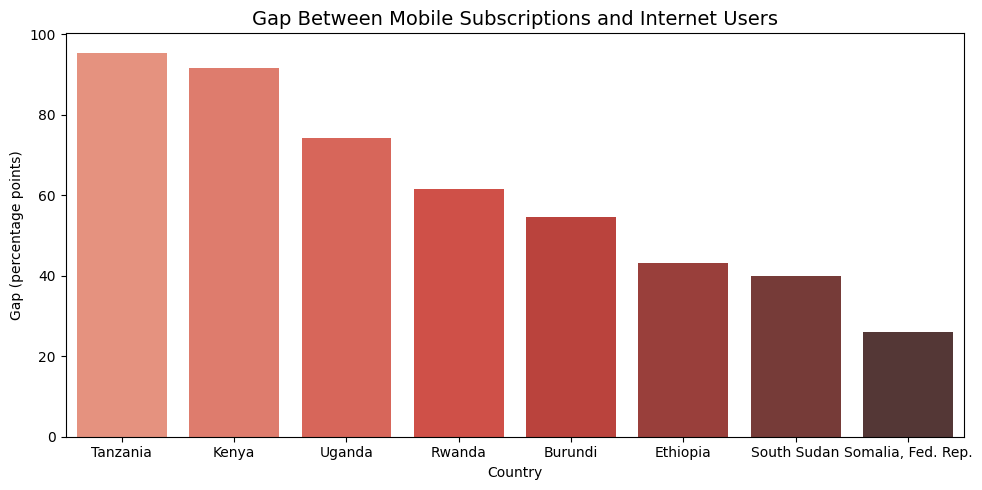

In [73]:
print("=" * 55)
print("Q4: Gap Between Mobile and Internet Adoption")
print("=" * 55)

gap = pd.DataFrame({
    'Mobile_Subscriptions(per100)': latest_mobile,
    'Internet_Users(%)': latest_internet
})
gap['Gap'] = (gap['Mobile_Subscriptions(per100)'] - gap['Internet_Users(%)']).round(2)
gap = gap.sort_values('Gap', ascending=False)

print(gap)
print(f"\nCountry with LARGEST gap: {gap['Gap'].idxmax()}")
print(f"Gap size: {gap['Gap'].max():.2f} points")

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=gap.index, y=gap['Gap'], palette='Reds_d')
plt.title("Gap Between Mobile Subscriptions and Internet Users", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Gap (percentage points)")
plt.tight_layout()
plt.show()

**Chart justification:** sorting by gap size makes the "largest gap" question directly readable. Best practices: single-hue sequential palette so colour encodes magnitude, data ordering carries the message.

## 5. How does Kenya compare with the other East African countries in terms of digital transformation?

Q5: Kenya vs Other East African Countries
                    Internet_Users(%)  Mobile_Subscriptions(per100)  \
country                                                               
Burundi                          8.60                         63.16   
Ethiopia                        21.94                         65.08   
Kenya                           34.98                        126.48   
Rwanda                          31.70                         93.20   
Somalia, Fed. Rep.              27.94                         53.96   
South Sudan                      6.67                         46.62   
Tanzania                        31.16                        126.56   
Uganda                           8.95                         83.17   

                    Electricity_Access(%)  
country                                    
Burundi                              20.1  
Ethiopia                             56.6  
Kenya                                77.0  
Rwanda                     

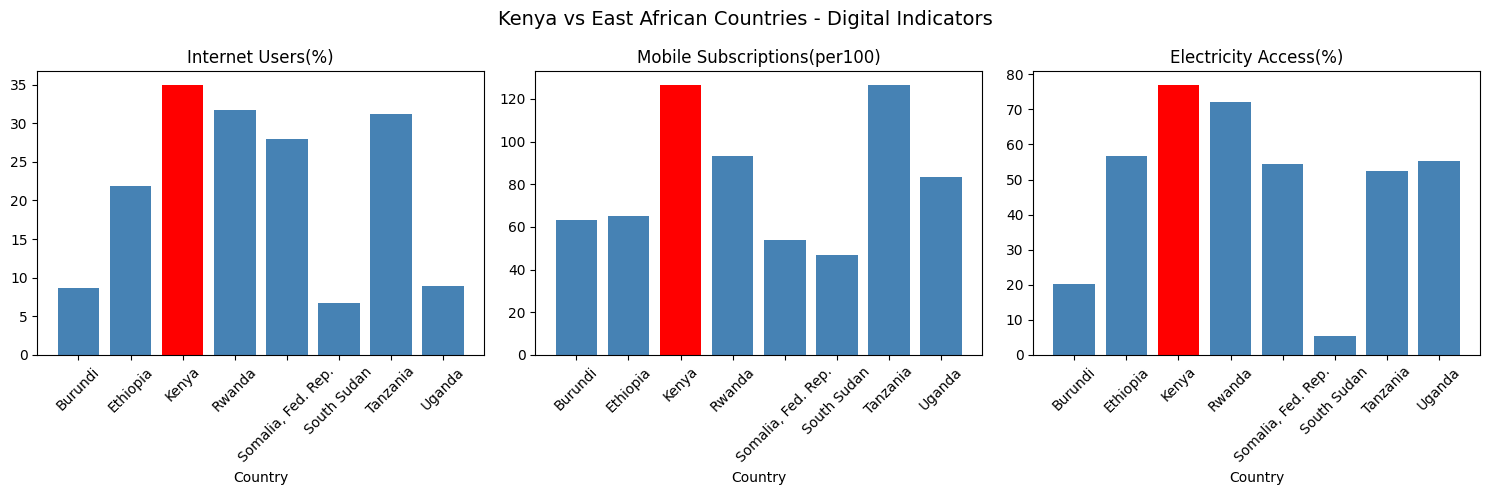

In [74]:
print("=" * 55)
print("Q5: Kenya vs Other East African Countries")
print("=" * 55)

kenya_comparison = pd.DataFrame({
    'Internet_Users(%)': latest_internet,
    'Mobile_Subscriptions(per100)': latest_mobile,
    'Electricity_Access(%)': latest_electric
}).round(2)

print(kenya_comparison)

# Highlight Kenya rank
for col in kenya_comparison.columns:
    ranked = kenya_comparison[col].rank(ascending=False)
    print(f"\nKenya rank in {col}: {int(ranked['Kenya'])} out of {len(ranked)}")

# Visualization - radar-style bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Kenya vs East African Countries - Digital Indicators", fontsize=14)

for i, col in enumerate(kenya_comparison.columns):
    colors = ['red' if c == 'Kenya' else 'steelblue'
              for c in kenya_comparison.index]
    axes[i].bar(kenya_comparison.index, kenya_comparison[col], color=colors)
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel("Country")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Chart justification:** small multiples compare Kenya against peers on three dimensions without overloading one axis; highlighting Kenya in a distinct colour applies the pre-attentive emphasis best practice.

## Comment:
Kenya is one of the leading East African countries in digital transformation, consistently ranking among the top in internet penetration and mobile subscriptions. This reflects Kenya's investments in ICT infrastructure, mobile money (M-Pesa), and digital government services.

## 6. Which three policy interventions would accelerate digital inclusion within the East African region? Every recommendation must be directly supported by evidence obtained during analysis.

In [75]:
print("=" * 55)
print("Q6: Policy Interventions for Digital Inclusion")
print("=" * 55)

top_gap = gap['Gap'].idxmax()
lag_2028 = fc_df[(fc_df['year'] == 2028) & (fc_df['forecast_%'] < 15)]['country'].tolist()
lead_2028 = fc_df[(fc_df['year'] == 2028) & (fc_df['forecast_%'] > 35)]['country'].tolist()

print(f"""
POLICY 1: COORDINATE ELECTRIFICATION WITH CONNECTIVITY INVESTMENT
Evidence: pooled-panel correlation between electricity access and
internet use is r = {corr} (p < 0.001, n = {len(merged)}), and the
regression confirms electricity remains a significant predictor after
controlling for mobile subscriptions. Countries with the lowest
electrification also have the lowest internet adoption. EACO should
advocate joint energy-connectivity planning: fibre along grid
extensions, solar-powered base stations off-grid.

POLICY 2: CONVERT CONNECTIVITY INTO USAGE (AFFORDABILITY AND DEVICES)
Evidence: in every country mobile subscriptions far exceed internet
use; the largest gap is {top_gap} ({gap['Gap'].max():.0f} points).
Networks reach far more people than use the internet, so the binding
constraints are demand-side. This pattern is consistent with
affordability barriers documented in ITU/A4AI regional pricing data.
Recommended: review sector-specific taxes on data and devices, and
zero-rate essential education and health services.

POLICY 3: TARGET UNIVERSAL SERVICE FUNDS AT THE DIVERGING COUNTRIES
Evidence: Holt forecasts show that on current trends the region
diverges by 2028 - leaders ({', '.join(lead_2028)}) approach 40%+
while laggards ({', '.join(lag_2028)}) remain below 15%. Without
targeted intervention the digital divide inside East Africa widens.
Recommended: prioritise USF disbursement and infrastructure-sharing
mandates in the lagging countries.
""")

Q6: Policy Interventions for Digital Inclusion

POLICY 1: COORDINATE ELECTRIFICATION WITH CONNECTIVITY INVESTMENT
Evidence: pooled-panel correlation between electricity access and
internet use is r = 0.744 (p < 0.001, n = 110), and the
regression confirms electricity remains a significant predictor after
controlling for mobile subscriptions. Countries with the lowest
electrification also have the lowest internet adoption. EACO should
advocate joint energy-connectivity planning: fibre along grid
extensions, solar-powered base stations off-grid.

POLICY 2: CONVERT CONNECTIVITY INTO USAGE (AFFORDABILITY AND DEVICES)
Evidence: in every country mobile subscriptions far exceed internet
use; the largest gap is Tanzania (95 points).
Networks reach far more people than use the internet, so the binding
constraints are demand-side. This pattern is consistent with
affordability barriers documented in ITU/A4AI regional pricing data.
Recommended: review sector-specific taxes on data and devices, and